
# Sıcaklık (Temperature), Örnekleme (Sampling) ve Geri Besleme Döngüsü (Autoregression)

Bu notebook, bir dil modelinin metin üretirken attığı son iki adımı kod üzerinden gösterir:

1. **Sıcaklık ve örnekleme** — model olasılıkları hesapladıktan sonra hangi kelimenin seçileceğine nasıl karar verilir?
2. **Geri besleme döngüsü (autoregression)** — üretilen kelime, bir sonraki tahminin girdisi nasıl olur?

Gerçek bir büyük dil modelinin ağırlıklarını indirmek yerine, mekanizmayı **küçük ve şeffaf bir "bigram" (ikili kelime) modeliyle** sıfırdan kuracağız. Matematik tamamen aynı: `logit → softmax(T) → örnekleme → döngü`. Tek fark, olasılıkları üreten "beyin" küçük bir istatistik tablosu, milyarlarca parametreli bir transformer değil.


In [1]:

import re                        # metni temizlemek ve kelimelere ayırmak için düzenli ifadeler
import numpy as np                # softmax, olasılık vektörleri ve rastgele örnekleme için
import matplotlib.pyplot as plt   # olasılık dağılımlarını çubuk grafikle çizmek için

# Tekrar üretilebilirlik için sabit tohum: aynı kodu tekrar çalıştırınca
# rastgele sayılar (örnekleme adımlarında) hep aynı çıksın, sonuçlar şansa bağlı görünmesin.
rng_global = np.random.default_rng(42)

# Grafiklerin görünümünü sadeleştiren ayarlar (üst ve sağ çizgileri kaldırır, çözünürlüğü artırır)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 1. Softmax ve sıcaklık (T)

Model her adımda kelime dağarcığındaki her kelime için bir **logit** (ham, normalize edilmemiş skor) üretir. Bu logitler `softmax` fonksiyonuyla olasılığa çevrilir:

$$ P(w_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}} $$

Burada **T (temperature)** devreye girer:

- **T → 0**: dağılım "keskinleşir", en yüksek logit neredeyse %100 olasılık alır → model her zaman en olası kelimeyi seçer (greedy gibi davranır).
- **T = 1**: logitler hiç ölçeklenmez, modelin "ham" olasılık dağılımı kullanılır.
- **T > 1**: dağılım "düzleşir", düşük olasılıklı kelimeler de şans kazanır → daha yaratıcı/rastgele ama riskli metin.

Aşağıda bunu somut sayılarla görelim.


In [2]:

def softmax_with_temperature(logits, T=1.0):
    """Logit vektörünü, T sıcaklığıyla ölçekleyip olasılık dağılımına çevirir."""
    logits = np.asarray(logits, dtype=float) / T   # 1. adım: her logiti T'ye böl (sıcaklık ölçekleme)
    logits = logits - logits.max()                 # 2. adım: en büyük değeri çıkar (sayısal kararlılık, e^büyük_sayı taşmasını engeller)
    exp_logits = np.exp(logits)                     # 3. adım: her ölçeklenmiş logitin e tabanındaki üssünü al
    return exp_logits / exp_logits.sum()             # 4. adım: toplama böl -> toplamı 1 olan bir olasılık dağılımı elde et


# Örnek: modelin 5 kelime için ürettiği varsayımsal ham logitler
kelimeler = ["kedi", "köpek", "kuş", "balık", "fil"]
logits = [2.0, 1.5, 0.5, 0.3, -1.0]   # logitler keyfi sayılardır, henüz olasılık değildir (negatif de olabilir, toplamları 1 değildir)

# Başlık satırını yazdır: sütun başına bir kelime adı
print(f"{'Sıcaklık':<10}" + "".join(f"{k:>10}" for k in kelimeler))

# Aynı logitleri farklı sıcaklıklarla deneyip her satırda bir T değerinin sonucunu yazdır
for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
    probs = softmax_with_temperature(logits, T)               # bu T için olasılık dağılımını hesapla
    print(f"T={T:<8}" + "".join(f"{p:>10.1%}" for p in probs))  # yüzde formatında satır satır yazdır


Sıcaklık        kedi     köpek       kuş     balık       fil
T=0.2          92.3%      7.6%      0.1%      0.0%      0.0%
T=0.5          68.8%     25.3%      3.4%      2.3%      0.2%
T=1.0          48.5%     29.4%     10.8%      8.9%      2.4%
T=1.5          39.3%     28.2%     14.5%     12.7%      5.3%
T=3.0          29.5%     25.0%     17.9%     16.7%     10.9%



Tabloda görüldüğü gibi `T=0.2`'de "kedi" tek başına dağılıma hâkim olurken, `T=3.0`'da bütün kelimeler birbirine yaklaşır. Aynı durumu grafikle de görselleştirelim.


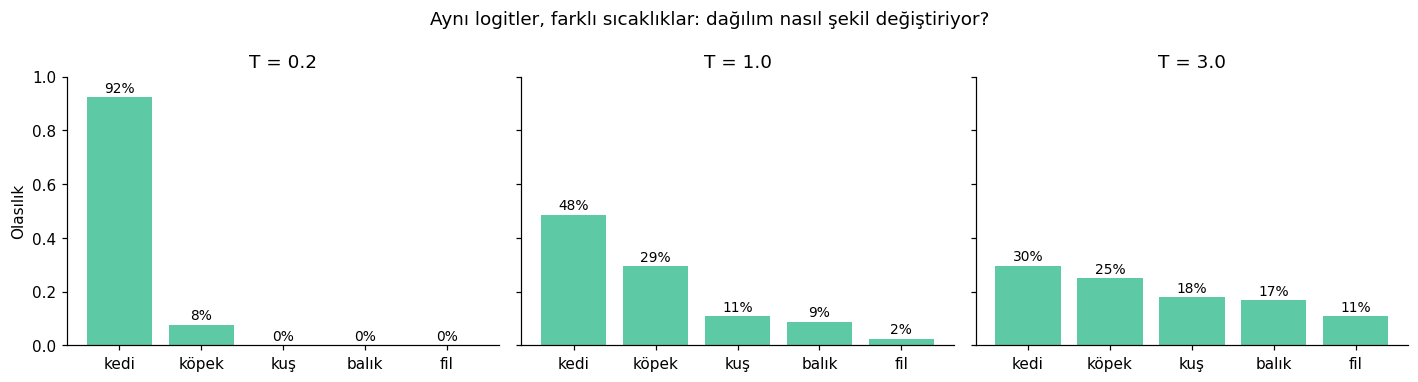

In [3]:

temperatures = [0.2, 1.0, 3.0]                                       # karşılaştırılacak üç sıcaklık değeri
fig, axes = plt.subplots(1, len(temperatures), figsize=(13, 3.5), sharey=True)  # yan yana 3 grafik alanı oluştur, y eksenini paylaştır

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, T)                       # bu sıcaklık için olasılıkları hesapla
    bars = ax.bar(kelimeler, probs, color="#5DCAA5")                    # her kelime için bir çubuk çiz
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)                                                   # y eksenini 0-1 (yüzde 0-100) aralığında sabitle
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02, f"{p:.0%}",  # çubuğun üstüne yüzde değerini yaz
                 ha="center", fontsize=9)

axes[0].set_ylabel("Olasılık")
fig.suptitle("Aynı logitler, farklı sıcaklıklar: dağılım nasıl şekil değiştiriyor?")
plt.tight_layout()
plt.show()



## 2. Örnekleme stratejileri

Olasılık dağılımı elimizdeyken, "hangi kelime seçilecek?" sorusunun birkaç farklı cevabı vardır:

- **Greedy (açgözlü)**: her zaman en yüksek olasılıklı kelime. Deterministiktir, aynı girdi her zaman aynı çıktıyı verir — ama tekdüze ve tekrara meyillidir.
- **Temperature sampling**: olasılıklara göre rastgele seçim (zar atmak gibi, ama zarın yüzleri eşit değil).
- **Top-k sampling**: sadece en olası **k** kelime arasından, olasılıklarına göre seçim yapılır; kuyruktaki anlamsız kelimeler elenir.
- **Top-p (nucleus) sampling**: kümülatif olasılığı **p**'yi (örn. %90) aşana kadar en olası kelimeler bir "havuza" alınır, seçim o havuzdan yapılır. k sabit değildir, dağılımın şekline göre değişir.

Bunları kodla uygulayalım.


In [4]:

def greedy_index(probs):
    # En yüksek olasılığa sahip elemanın indeksini döndürür -> her zaman aynı seçim, rastgelelik yok
    return int(np.argmax(probs))


def temperature_sample_index(probs, rng):
    # probs dizisini ağırlık olarak kullanarak rastgele bir indeks çeker (zar atmak gibi)
    return int(rng.choice(len(probs), p=probs))


def top_k_index(probs, k, rng):
    k = min(k, len(probs))                      # k, eleman sayısından büyük olamaz
    top_idx = np.argsort(probs)[-k:]            # en yüksek k olasılığın indeksleri (küçükten büyüğe sıralayıp son k'yı al)
    top_probs = probs[top_idx]
    top_probs = top_probs / top_probs.sum()      # havuzu yeniden normalize et (toplamları yine 1 olsun)
    return int(rng.choice(top_idx, p=top_probs))  # sadece bu k'lık havuzdan örnekle


def top_p_index(probs, p, rng):
    order = np.argsort(probs)[::-1]              # büyükten küçüğe sırala
    sorted_probs = probs[order]
    cumulative = np.cumsum(sorted_probs)          # kümülatif (biriken) olasılık toplamı
    cutoff = int(np.searchsorted(cumulative, p)) + 1  # kümülatif toplam p'yi geçtiği ilk noktayı bul
    pool_idx = order[:cutoff]                     # havuz: kümülatif olasılığı p'ye getiren en olası kelimeler
    pool_probs = probs[pool_idx]
    pool_probs = pool_probs / pool_probs.sum()     # havuzu yeniden normalize et
    return int(rng.choice(pool_idx, p=pool_probs))  # sadece bu (değişken boyutlu) havuzdan örnekle


# Aynı dağılım üzerinde dört stratejiyi karşılaştıralım
probs_demo = softmax_with_temperature(logits, T=1.0)  # T=1.0: ölçeklenmemiş "ham" dağılım
rng = np.random.default_rng(7)                          # bu hücreye özel, sabit bir rastgelelik kaynağı

print("Dağılım:", dict(zip(kelimeler, np.round(probs_demo, 3))))
print("Greedy        ->", kelimeler[greedy_index(probs_demo)])
print("Temperature   ->", kelimeler[temperature_sample_index(probs_demo, rng)])
print("Top-k (k=2)   ->", kelimeler[top_k_index(probs_demo, 2, rng)])
print("Top-p (p=0.8) ->", kelimeler[top_p_index(probs_demo, 0.8, rng)])


Dağılım: {'kedi': np.float64(0.485), 'köpek': np.float64(0.294), 'kuş': np.float64(0.108), 'balık': np.float64(0.089), 'fil': np.float64(0.024)}
Greedy        -> kedi
Temperature   -> köpek
Top-k (k=2)   -> kedi
Top-p (p=0.8) -> köpek



## 3. Geri besleme döngüsü (autoregression) için minik bir "beyin": bigram modeli

Gerçek bir transformer, önceki **tüm** bağlamı dikkat (attention) mekanizmasıyla tarar ve her adımda yeni bir olasılık dağılımı üretir. Biz burada işi basitleştirip, sadece **son kelimeye bakarak** bir sonraki kelimenin olasılığını tahmin eden bir model kuracağız (bigram). Döngünün mantığı —*tahmin et, örnekle, ekle, başa dön*— birebir aynıdır; sadece tahmin adımının içi çok daha basit.

Önce küçük bir Türkçe metin üzerinde kelime geçiş istatistiklerini çıkaralım.


In [5]:

corpus = """
Bugün hava çok güzeldi. Bugün hava biraz bulutluydu. Bugün hava aniden bozdu.
Güneş erkenden doğdu ve ortalığı aydınlattı. Güneş öğleden sonra kayboldu ve
hava kararttı. Çocuklar parkta oynadı ve güldü. Çocuklar parkta koştu ve
yoruldu. Çocuklar bahçede saklambaç oynadı. Köpekler bahçede koştu ve havladı.
Köpekler bahçede uyukladı. Akşam olunca rüzgar şiddetlendi ve yapraklar
uçuştu. Akşam olunca gökyüzü kızıla döndü. Akşam olunca herkes evine çekildi.
Yağmur birden başladı ve sokakları ıslattı. Yağmur kısa sürdü ve hemen durdu.
Yağmur uzun sürdü ve göletler oluştu. Yağmur birden bastırdı ve herkes kaçıştı.
İnsanlar şemsiyelerini açtı ve yürüdü.
İnsanlar pencereden dışarı baktı. Gece olunca gökyüzü yıldızlarla doldu.
Gece olunca ay parlak bir şekilde belirdi. Gece olunca sessizlik çöktü.
Herkes evine huzur içinde döndü. Herkes mutlu bir şekilde uyudu. Bugün hava
çok değişkendi ama güzel bir gündü.
"""


def tokenize(text):
    text = text.replace("İ", "i").replace("I", "ı")  # Türkçe büyük/küçük harf tuzağı: Python'ın varsayılan .lower() "İ"yi yanlış çevirir
    text = text.lower()                                # tüm metni küçük harfe çevir (aksi halde "Hava" ve "hava" farklı kelime sayılır)
    text = re.sub(r"[^\w\sçğıöşüâî]", " ", text, flags=re.UNICODE)  # noktalama işaretlerini boşlukla değiştir, Türkçe harfleri koru
    return text.split()                                  # boşluklardan böl -> kelime listesi döndür


tokens = tokenize(corpus)
print(f"Toplam token sayısı: {len(tokens)}")
print(f"Benzersiz kelime sayısı: {len(set(tokens))}")
print("İlk 15 token:", tokens[:15])


Toplam token sayısı: 131
Benzersiz kelime sayısı: 80
İlk 15 token: ['bugün', 'hava', 'çok', 'güzeldi', 'bugün', 'hava', 'biraz', 'bulutluydu', 'bugün', 'hava', 'aniden', 'bozdu', 'güneş', 'erkenden', 'doğdu']


In [6]:

# Bigram sayım tablosu: bigram_counts["hava"] = {"çok": 2, "birden": 1, ...}
bigram_counts = {}
# zip(tokens[:-1], tokens[1:]) -> her kelimeyi kendinden sonraki kelimeyle eşler:
# [bugün, hava, çok, ...] üzerinde (bugün, hava), (hava, çok), ... çiftlerini gezer
for current_word, next_word in zip(tokens[:-1], tokens[1:]):
    bigram_counts.setdefault(current_word, {})                                   # bu kelime ilk kez görülüyorsa boş bir sözlük aç
    bigram_counts[current_word][next_word] = bigram_counts[current_word].get(next_word, 0) + 1  # sayacı bir artır

# "hava" kelimesinden sonra hangi kelimeler hangi sıklıkla geliyor?
print("'hava' kelimesinden sonra gözlenen kelimeler:")
for kelime, sayi in bigram_counts["hava"].items():
    print(f"  {kelime!r:<12} -> {sayi} kez")


'hava' kelimesinden sonra gözlenen kelimeler:
  'çok'        -> 2 kez
  'biraz'      -> 1 kez
  'aniden'     -> 1 kez
  'kararttı'   -> 1 kez



## 4. Tahmin adımı: sayımlardan logit'e, logit'ten olasılığa

Gerçek bir modelde logitler attention katmanlarından çıkar; burada ise **gözlenen sayımların logaritması** logit rolünü üstleniyor (`+1` ekleyerek hiç görülmemiş bir kelime sıfır olasılıkla değil, küçük bir olasılıkla başlasın — bu, gerçek modellerdeki "smoothing" mantığının basitleştirilmiş hâli). Üzerine sıcaklık uygulanmış softmax geliyor.


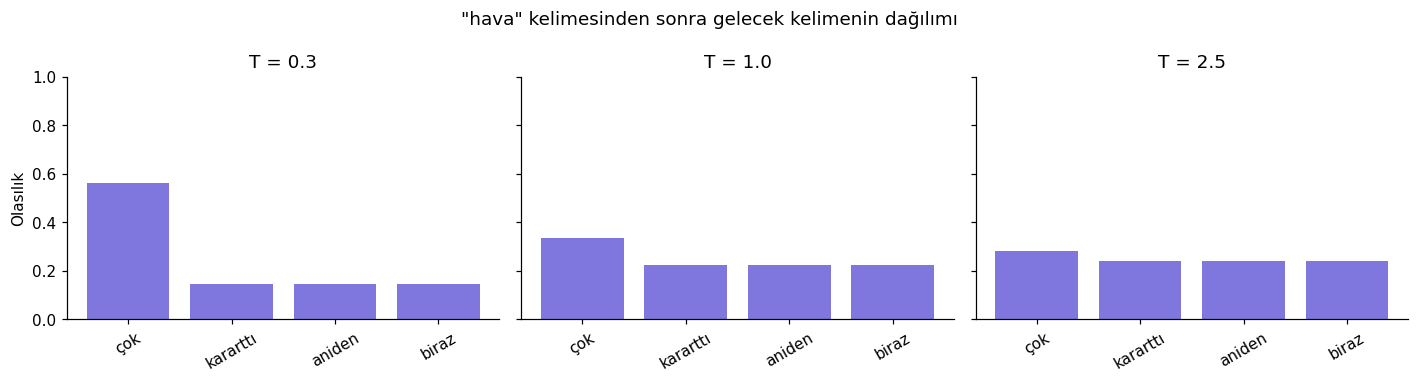

In [7]:

def predict_next_word(current_word, temperature=1.0):
    """current_word'den sonra gelebilecek kelimelerin (kelime_listesi, olasılık_dizisi) çiftini döndürür.
    current_word hiç görülmemişse None döner (zincir kopar)."""
    if current_word not in bigram_counts:
        return None                                                  # bu kelimeden sonrası hiç gözlenmedi -> tahmin yapılamaz
    candidates = list(bigram_counts[current_word].keys())              # bu kelimeden sonra gözlenen tüm farklı kelimeler
    counts = np.array([bigram_counts[current_word][c] for c in candidates], dtype=float)  # her birinin kaç kez gözlendiği
    pseudo_logits = np.log(counts + 1.0)           # sayım -> "logit" (log almak büyük sayım farklarını yumuşatır; +1 hiç görülmemiş ihtimale küçük bir pay bırakır)
    probs = softmax_with_temperature(pseudo_logits, temperature)  # sıcaklık uygulanmış softmax ile olasılığa çevir
    return candidates, probs


# "hava" kelimesi için farklı sıcaklıklarda dağılımı görselleştirelim
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, T in zip(axes, [0.3, 1.0, 2.5]):
    candidates, probs = predict_next_word("hava", T)        # bu sıcaklık için (kelime listesi, olasılık) çiftini al
    order = np.argsort(probs)[::-1]                          # en olasıdan en az olasıya doğru sırala (sadece görsel düzen için)
    ax.bar(np.array(candidates)[order], probs[order], color="#7F77DD")
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Olasılık")
fig.suptitle('"hava" kelimesinden sonra gelecek kelimenin dağılımı')
plt.tight_layout()
plt.show()



## 5. Döngü adımı: autoregression'ı çalışır hâle getirmek

Artık zincirleme reaksiyonun bütün parçaları elimizde. `generate()` fonksiyonu, sorudaki 5 adımı tam olarak uygular:

```
girdi (son kelime) -> tahmin (predict_next_word) -> örnekleme (sample_*) -> ekle -> başa dön
```

Üretilen her kelime, kendisinin bir sonraki adımın girdisi olmasını sağlar — bu satır, "geri besleme döngüsü"nün kod karşılığıdır.


In [8]:

def generate(seed_word, steps=12, temperature=1.0, strategy="temperature", k=3, p=0.9, seed=None):
    """seed_word'den başlayıp, her adımda bir kelime tahmin edip örnekleyerek steps adım boyunca metin üretir.
    strategy: 'greedy' | 'temperature' | 'top_k' | 'top_p' — örnekleme stratejisini belirler.
    seed: rastgele sayı üretecinin tohumu (aynı seed -> aynı rastgele çıktı, tekrar üretilebilirlik için)."""
    rng = np.random.default_rng(seed)     # bu üretim için özel bir rastgelelik kaynağı
    current = seed_word.lower()            # girdi: zincirin başlangıç kelimesi
    sequence = [current]                   # üretilen tüm dizi burada birikecek

    for _ in range(steps):                  # döngü: toplam steps kez "tahmin et -> örnekle -> ekle" yap
        result = predict_next_word(current, temperature)   # tahmin: current'tan sonraki kelimelerin olasılık dağılımı
        if result is None:
            sequence.append("...[zincir koptu: bu kelimeden sonrası gözlenmedi]")
            break                                              # bigram tablosunda devamı yoksa döngüyü durdur

        candidates, probs = result

        # örnekleme: strategy parametresine göre dağılımdan bir indeks seç
        if strategy == "greedy":
            idx = greedy_index(probs)              # her zaman en olası kelime
        elif strategy == "top_k":
            idx = top_k_index(probs, k, rng)        # en olası k kelime arasından örnekle
        elif strategy == "top_p":
            idx = top_p_index(probs, p, rng)        # kümülatif olasılığı p'ye getiren havuzdan örnekle
        else:  # "temperature"
            idx = temperature_sample_index(probs, rng)  # tüm dağılımdan olasılıklara göre örnekle

        next_word = candidates[idx]    # seçilen kelime
        sequence.append(next_word)      # ekle: kelimeyi üretilen diziye ekle
        current = next_word             # <-- AUTOREGRESSION: çıktı, yeni girdi oluyor; döngü bu satırla "başa dönüyor"

    return " ".join(sequence)


print("Greedy (T etkisiz, her zaman en olası kelime):")
print(" ", generate("bugün", steps=14, strategy="greedy"))
print()
print("Temperature sampling, T=0.3 (tutucu):")
print(" ", generate("bugün", steps=14, temperature=0.3, seed=1))
print()
print("Temperature sampling, T=1.5 (yaratıcı/riskli):")
print(" ", generate("bugün", steps=14, temperature=1.5, seed=1))


Greedy (T etkisiz, her zaman en olası kelime):
  bugün hava çok güzeldi bugün hava çok güzeldi bugün hava çok güzeldi bugün hava çok

Temperature sampling, T=0.3 (tutucu):
  bugün hava kararttı çocuklar bahçede saklambaç oynadı köpekler bahçede koştu ve göletler oluştu yağmur kısa

Temperature sampling, T=1.5 (yaratıcı/riskli):
  bugün hava kararttı çocuklar bahçede saklambaç oynadı köpekler bahçede koştu ve göletler oluştu yağmur uzun



Greedy çıktıya dikkat edin: model her adımda en olası kelimeyi seçtiği için aynı kelime grupları arasında **döngüye girip tekrar etme** eğilimi gösterir — sorudaki "uzun metinlerde tekrar etme" sorununun en saf hâli budur. `T=1.5` çıktısında ise daha fazla çeşitlilik var, ama bağlamla bağ daha kolay kopuyor (bizim minik bigram modelimizde bu özellikle belirgin, çünkü modelin hafızası sadece bir önceki kelimeyle sınırlı).

Tek bir rastgele örnekleme şans eseri yanıltıcı olabilir (aynı zar birkaç kez art arda aynı sayıyı getirebilir). Sıcaklığın etkisini daha güvenilir görmek için, `"yağmur"` kelimesinden sonraki **ilk** kelime seçimini her sıcaklıkta 300 kez tekrarlayıp ortaya çıkan dağılımı ölçelim.


In [9]:

from collections import Counter   # seçilen kelimelerin kaç kez tekrarlandığını saymak için

n_deneme = 300
print(f'"yağmur" kelimesinden sonra {n_deneme} denemede seçilen kelimelerin dağılımı:\n')

for T in [0.2, 0.7, 1.5, 3.0]:
    candidates, probs = predict_next_word("yağmur", T)   # bu sıcaklık için teorik dağılımı hesapla (bir kez, döngü dışında)
    secimler = []
    for trial in range(n_deneme):
        rng_trial = np.random.default_rng(trial)          # her deneme için farklı ama sabit bir tohum (tekrar üretilebilir rastgelelik)
        idx = temperature_sample_index(probs, rng_trial)   # aynı dağılımdan bir kez daha "zar at"
        secimler.append(candidates[idx])
    sayim = Counter(secimler)                                # hangi kelime kaç kez seçildi?
    dagilim = ", ".join(f"{k}: %{100*v/n_deneme:.0f}" for k, v in sayim.most_common())  # yüzdeye çevirip yazdır
    print(f"T={T:<4} -> {dagilim}")


"yağmur" kelimesinden sonra 300 denemede seçilen kelimelerin dağılımı:

T=0.2  -> birden: %74, uzun: %13, kısa: %12
T=0.7  -> birden: %38, kısa: %31, uzun: %31
T=1.5  -> uzun: %36, kısa: %33, birden: %31
T=3.0  -> uzun: %38, kısa: %34, birden: %28



Görüldüğü gibi `T=0.2`'de model büyük ölçüde en sık gözlenen kelimeyi ("birden", ~%74) seçiyor; `T=3.0`'a çıkıldığında ise üç seçenek de birbirine yakın oranlarda paylaşılıyor. Bu, ilk bölümdeki teorik softmax tablosunun örneklemede gerçekten karşılığını doğruluyor: sıcaklık, dağılımı *fiilen* keskinleştiriyor veya düzleştiriyor — sadece kâğıt üzerinde değil, üretilen metinde de.



## 6. Top-k ve top-p ile autoregression

Son olarak, aynı döngüyü top-k ve top-p örneklemeyle çalıştırıp temperature sampling ile karşılaştıralım. Bu iki strateji, "çok düşük olasılıklı/anlamsız kelimelerin seçilme riskini" azaltırken hâlâ bir rastgelelik payı bırakır — pratikte modern dil modellerinde temperature ile birlikte en sık kullanılan kombinasyon budur.


In [10]:

# Aynı seed_word, aynı sıcaklık (T=1.2) ve aynı rastgelelik tohumu (seed=5) ile üç farklı
# örnekleme stratejisini karşılaştırıyoruz; tek değişen değişken strategy parametresi.
print("Temperature (T=1.2):", generate("gece", steps=12, temperature=1.2, strategy="temperature", seed=5))
print("Top-k (k=2, T=1.2):  ", generate("gece", steps=12, temperature=1.2, strategy="top_k", k=2, seed=5))
print("Top-p (p=0.85,T=1.2):", generate("gece", steps=12, temperature=1.2, strategy="top_p", p=0.85, seed=5))


Temperature (T=1.2): gece olunca ay parlak bir şekilde belirdi gece olunca rüzgar şiddetlendi ve güldü
Top-k (k=2, T=1.2):   gece olunca gökyüzü yıldızlarla doldu gece olunca sessizlik çöktü herkes evine huzur içinde
Top-p (p=0.85,T=1.2): gece olunca herkes mutlu bir şekilde uyudu bugün hava çok güzeldi bugün hava



## Özet: zincirleme reaksiyon, kod karşılığıyla

| Adım | Kavram | Bu notebook'taki karşılığı |
|---|---|---|
| 1. Girdi | Padding ile düzenleme | `tokenize()` ile metni kelimelere ayırma |
| 2. Konumlandırma | Sıra belirleme | `zip(tokens[:-1], tokens[1:])` ile bigram sırası |
| 3. Dikkat | Kelime ilişkileri | Bigram sayım tablosu (`bigram_counts`) — basitleştirilmiş "ilişki" |
| 4. Tahmin | Olasılık belirleme | `predict_next_word()` → `softmax_with_temperature()` |
| 5. Döngü | Yeni kelime ekleme, başa dönme | `generate()` içindeki `current = next_word` satırı |

Gerçek bir büyük dil modelinde 3. ve 4. adımlar çok daha güçlüdür (çok katmanlı self-attention, milyarlarca parametre, tüm bağlamı görme), ama 5. adımdaki **döngü mantığı** —yeni token'ı geçmişe ekleyip yeniden tahmin etmek— tam olarak burada gördüğünüz gibidir. Bu yüzden sıcaklık ve örnekleme stratejisi seçimi, modelin büyüklüğünden bağımsız olarak üretilen metnin "ruhunu" belirleyen en pratik kontrol noktasıdır.
